# Image Classification: Cats vs Dogs
## 1. Import Packages

In [1]:
import os
import numpy as np

import torch
import torch.nn as nn
import torchvision
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

## 2. Pre-Produce

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
# dataset pre-produce class
classes = {0:"dog", 1:"cat"}
class MyDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        if transform is None:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                transforms.Resize((128,128))
            ])
        else:
            self.transform = transform
        self.img_list = os.listdir(self.data_path)
    
    # create label
    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        if img_name.split('.')[0] == 'cat':
            label = 1
        else:
            label = 0
        label = torch.as_tensor(label, dtype=torch.int64)
        img_path = os.path.join(self.data_path, img_name)
        img = Image.open(img_path)
        img = self.transform(img)
        return img, label
    
    def __len__(self):
        return len(self.img_list)

In [4]:
# convert RGB to Gray
def rgb2gray(rgb_path, gray_path):
    # get imgs' paths
    paths = [os.path.join(rgb_path, fname) for fname in os.listdir(rgb_path)]
    for path in tqdm(paths):
        img = Image.open(path).convert('L')
        if not os.path.exists(gray_path):
            os.makedirs(gray_path)
        img.save(gray_path+"\\"+path.split('\\')[-1])
    print("Convert Finished.")

## 3. Load datasets

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99318683..1.0].


(<matplotlib.image.AxesImage at 0x20e0c197850>, torch.Size([3, 128, 128]))

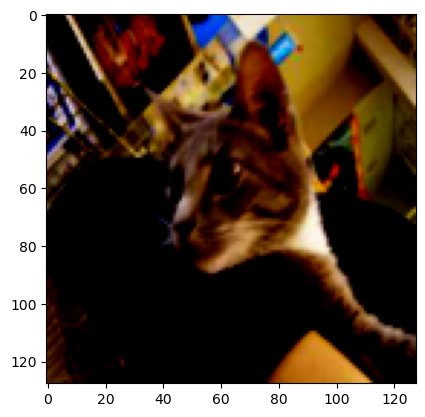

In [5]:
# used net name
net_name = "CNN"
create_gray = False

train_path = "data/mini/train"
test_path = "data/mini/val"
gray_train_path = "data/mini/gray/train"
gray_test_path = "data/mini/gray/test"
# for rnn, use gray images
if net_name == "RNN":
    # convert RGB to Gray
    if create_gray is True:
        rgb2gray(train_path, gray_train_path)
        rgb2gray(test_path, gray_test_path)
    # load datasets, for gray images, need to redefine transform param
    rnn_train_set = MyDataset(gray_train_path, transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,)),
                transforms.Resize((128,128))
            ]))
    rnn_test_set = MyDataset(gray_test_path, transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,)),
                transforms.Resize((128,128))
            ]))
    # create rnn loader
    train_loader = torch.utils.data.DataLoader(rnn_train_set, batch_size=32, shuffle=True)
    test_loader = torch.utils.data.DataLoader(rnn_test_set, batch_size=32, shuffle=True)
else:
    # load datasets
    train_set = MyDataset(train_path)
    test_set = MyDataset(test_path)
    # create loader
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=True)

# show
dataiter = iter(train_loader)
imgs, _ = next(dataiter)      
imshow(torchvision.utils.make_grid(imgs[0].permute(1,2,0))), imgs[0].shape

## 4. Nets
### DNN

In [6]:
# DNN
class DNN(nn.Module):
    def __init__(self):
        super(DNN,self).__init__() 
        self.seq = nn.Sequential(
            nn.Flatten(), # flatten all dimensions except batch from start_dim=1
            nn.Linear(3*128*128, 1024, bias=True), 
            nn.ReLU(),
            nn.Linear(1024, 512, bias=True),
            nn.ReLU(),
            nn.Linear(512, 2, bias=True),
            nn.Softmax(dim=1),
        )
        
    def forward(self, x):
        out = self.seq(x)
        return out

### CNN

In [7]:
# CNN
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5, padding=1, stride=1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1, stride=1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(),
        )
        self.fc = nn.Linear(256*15*15, 2, bias=True)
        
    def forward(self, x):
        out= self.conv1(x)
        out= self.conv2(out)
        out= self.conv3(out)
        out = torch.flatten(out, start_dim=1)
        out = self.fc(out)
        return out

### RNN

In [8]:
# RNN

class RNN(nn.Module):
    def __init__(self):
        super(RNN,self).__init__()
        # input_size is input feature size (of one token);
        # hidden_size is output feature size (of one input token) (equals to hidden feature size)
        # num_layers is number of rnn layers
        self.rnn = nn.RNN(input_size=128, hidden_size=256, num_layers=2, batch_first=True)
        self.fc = nn.Linear(256, 2)
            
    def forward(self, x):
        # 2D Image inputs from up to low, A image shape (H x W) just like (seq_length x feature size).
        x = x.view(-1, 128, 128) # rnn input should be (batch, seq_length, feature size). 
        out, hidden_state = self.rnn(x)
        # output is (batch, seq_length, hidden_size*direction). direction here equals 1(in bidirectional rnn equals 2).
        out = out[:,-1,:] # in rnn, we only use the last output(y_n) as final output(it contains image all features).
        out = self.fc(out)
        return out

### Load Net Model

In [9]:
if net_name == "DNN":
    net = DNN().to(device)
elif net_name == "CNN":
    net = CNN().to(device)
else:
    net = RNN().to(device)
print(net)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
  )
  (fc): Linear(in_features=57600, out_features=2, bias=True)
)


## 5. Optimizer and Loss Function

In [10]:
# create optimizer
optimizer = torch.optim.SGD(net.parameters(), lr=1e-3, momentum=0.9)

# create loss
loss_func = nn.CrossEntropyLoss()

## 6. Train

In [11]:
# train
epochs = 10
N = 5
loss_list = []
for epoch in range(epochs):
    loss_list.append([])
loss_accumulate = 0.0
# set train mode
net.train()
# start train
print("Start Training...")
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    for i, (inputs, labels) in enumerate(tqdm(train_loader)):
        # get the inputs; data in train_loader is a mini-batch of [inputs, labels]
        inputs, labels = inputs.to(device), labels.to(device)
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward
        outputs = net(inputs)
        # print(outputs.shape)
        # loss compute
        loss = loss_func(outputs, labels)
        # backward
        loss.backward()
        # update
        optimizer.step()
        
        # for plot
        # progress bar drawing control
        # left_length_ratio = (i+1)/len(train_loader)
        # right_length_ratio = 1.0-left_length_ratio
        # bar_length = 50
        # accumulate loss of every 1000 mini-batches
        loss_accumulate += loss.item()
        if i % N == N-1: # record avg loss every N mini-batches
            loss_list[epoch].append(loss_accumulate/N)
            loss_accumulate = 0.0
        # print(f'\r{100*(i+1)//len(train_loader):3d}% [', 
        #       f'▓'*int(left_length_ratio*bar_length), 
        #       ' '*int(right_length_ratio*bar_length), 
        #       f'] {(i+1):3d}/{len(train_loader):3d}', 
        #       end='\r')
    
    print(f'epoch {epoch} last mini-batch loss: {loss_list[epoch][-1]:.3f}')

     
print("Finished Training.")

Start Training...
epoch: 0


100%|██████████| 63/63 [00:07<00:00,  8.03it/s]


epoch 0 last mini-batch loss: 0.697
epoch: 1


100%|██████████| 63/63 [00:07<00:00,  8.69it/s]


epoch 1 last mini-batch loss: 0.664
epoch: 2


...

epoch 7 last mini-batch loss: 0.621
epoch: 8


100%|██████████| 63/63 [00:08<00:00,  7.68it/s]


epoch 8 last mini-batch loss: 0.525
epoch: 9


100%|██████████| 63/63 [00:08<00:00,  7.63it/s]

epoch 9 last mini-batch loss: 0.583
Finished Training.


Text(0.5, 1.0, 'epoch=9, train loss')

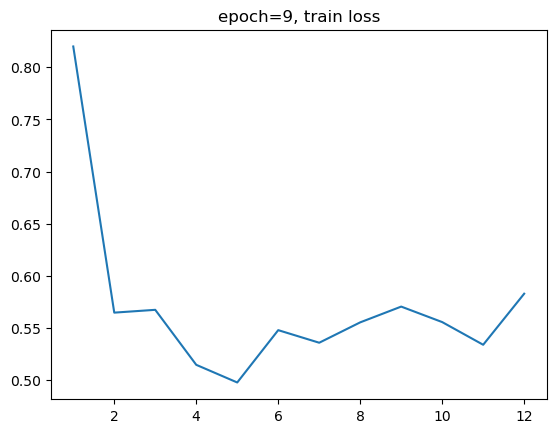

In [12]:
# plot
plt.plot(np.arange(1, len(loss_list[epoch])+1), loss_list[epoch])
plt.title(f"epoch={epochs-1}, train loss")

In [13]:
# save model
print(net._get_name())
save_path = f'model/{net._get_name()}.pth'
torch.save(net.state_dict(), save_path)

CNN


## 7. Test

In [14]:
# test
# load model
load_path = f'model/{net._get_name()}.pth'
net.load_state_dict(torch.load(load_path))
print(net.state_dict())

OrderedDict([('conv1.0.weight', tensor([[[[ 0.1043,  0.0277, -0.0676,  0.0155, -0.0487],
          [ 0.0390, -0.0056,  0.0326, -0.0610,  0.1008],
          [-0.0502, -0.0716, -0.0323, -0.0996, -0.0096],
          [ 0.0211, -0.0819, -0.0689, -0.0833, -0.0809],
          [ 0.0190, -0.0745, -0.0275, -0.0525,  0.0618]],

         [[-0.0660,  0.1132,  0.0838, -0.1156,  0.0270],
          [ 0.0562, -0.0555, -0.1155,  0.0252, -0.0625],
          [ 0.0193, -0.0182,  0.0483,  0.0204, -0.1142],
          [ 0.0148,  0.0787, -0.0697, -0.0832, -0.0223],
          [ 0.0672, -0.1064,  0.0922, -0.0108,  0.0330]],

         [[-0.0063, -0.0610, -0.0943, -0.1037, -0.1110],
          [ 0.0618,  0.0034,  0.0162, -0.0960,  0.0325],
          [-0.0463, -0.0612, -0.0113,  0.0892, -0.0955],
          [ 0.0011,  0.0956, -0.0192, -0.0640,  0.0787],
          [-0.0471, -0.0525, -0.1026, -0.0849, -0.0263]]],


        [[[ 0.0270,  0.0973, -0.0283, -0.0887, -0.0519],
          [ 0.0055,  0.0300, -0.0867,  0.0209,  

D:\workdata\software\TEMP\USERTEMP\ipykernel_31884\3809958387.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(load_path))


In [15]:
# compute accuracy
correct = 0
total = 0
# set evaluate mode
net.eval()
with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(test_loader)):
        images = images.to(device)
        labels = labels.to(device)
        y_hats = net(images)
        _, predicted = torch.max(y_hats.data, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

100%|██████████| 16/16 [00:01<00:00,  8.54it/s]

Accuracy of the network on the 500 test images: 66 %


In [16]:
# compute each class accuracy
correct_pred = {classname: 0 for classname in classes.values()}
total_pred = {classname: 0 for classname in classes.values()}

net.eval()
with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        y_hats = net(images)
        _, predictions = torch.max(y_hats, dim=1)
        # collect the correct predictions for each class
        for label, predicted in zip(labels, predictions):
            label = label.item()
            predicted = predicted.item()
            if label == predicted:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * correct_count / total_pred[classname]
    print(f'Accuracy for {classname} : {accuracy} %')

Accuracy for dog : 70.4 %
Accuracy for cat : 62.8 %
